In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
import pickle
from collections import defaultdict

In [2]:
# --- Global rcParams ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 22,       # Axis labels fontsize
    "xtick.labelsize": 18,      # X tick labels fontsize
    "ytick.labelsize": 18,      # Y tick labels fontsize
    "xtick.direction": "in",    # X ticks inward
    "ytick.direction": "in",    # Y ticks inward
    "xtick.top": True,          # Show ticks on top
    "ytick.right": True,        # Show ticks on right
    #"axes.grid": True,          # Enable grid
    #"grid.linestyle": "--",     # Grid style
    #"grid.alpha": 0.4           # Grid transparency
})

In [3]:
# --- Load pickled dictionary ---
with open("./Creep_Tests_E0_e-4_out_6_10_2025/parametric_curves_creep.pkl", "rb") as f:
    parametric_curves_creep = pickle.load(f)

In [4]:
# --- Display keys ---
print("Keys:")
for k in parametric_curves_creep.keys():
    print(k)

Keys:
('-1.9994001e+11', '1000.00000000')
('-1.9994002e+13', '1000.00000000')
('-1.9994002e+15', '1000.00000000')
('-1.960592e+11', '1000.00000000')
('-1.9605921e+13', '1000.00000000')
('-1.9605921e+15', '1000.00000000')
('-6.6664443e+10', '1000.00000000')
('-6.6664444e+12', '1000.00000000')
('-6.6664444e+14', '1000.00000000')
('-1.9994001e+11', '10.00000000')
('-1.9994002e+13', '10.00000000')
('-1.9994002e+15', '10.00000000')
('-1.960592e+11', '10.00000000')
('-1.9605921e+13', '10.00000000')
('-1.9605921e+15', '10.00000000')
('-6.6664443e+10', '10.00000000')
('-6.6664444e+12', '10.00000000')
('-6.6664444e+14', '10.00000000')
('-1.9994001e+11', '0.10000000')
('-1.9994002e+13', '0.10000000')
('-1.9994002e+15', '0.10000000')
('-1.960592e+11', '0.10000000')
('-1.9605921e+13', '0.10000000')
('-1.9605921e+15', '0.10000000')
('-6.6664443e+10', '0.10000000')
('-6.6664444e+12', '0.10000000')
('-6.6664444e+14', '0.10000000')
('-1.9994001e+11', '0.00100000')
('-1.9994002e+13', '0.00100000')
('-1

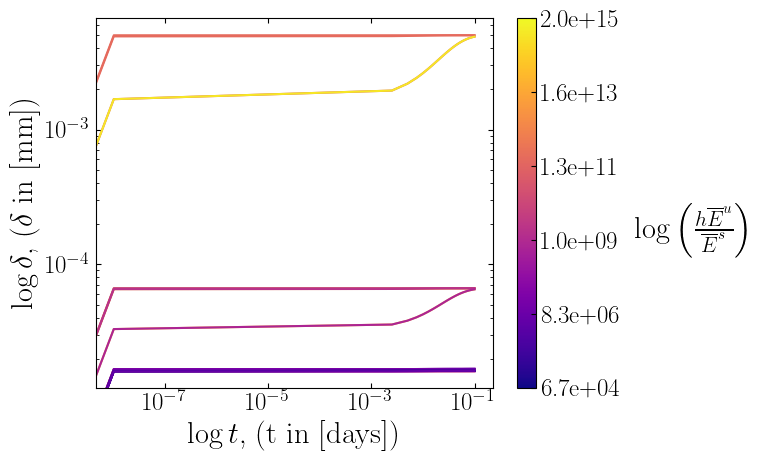

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- extract all a-values as floats
a_vals = [np.abs(float(key[0])) for key in list(parametric_curves_creep.keys()) if key[1]== '1000.00000000']
a_min, a_max = min(a_vals), max(a_vals)
parametric_curves_creep_keys =list( parametric_curves_creep.keys())

select_parametric_curves_creep_dict = {k: parametric_curves_creep[k] for k in parametric_curves_creep_keys[:] if k[1]== '1000.00000000'}
# --- continuous colormap
cmap = plt.colormaps["plasma"]
#norm = plt.Normalize(vmin=a_min, vmax=a_max)
norm = LogNorm(vmin=a_min, vmax=a_max)

fig, ax = plt.subplots()

# --- loop and plot each curve with its own color
for (a, b), data_entry in select_parametric_curves_creep_dict.items():
    a_float = np.abs(float(a))  # force numeric
    color = cmap(norm(a_float))
    time, displacement, force, stress = data_entry
    ax.plot(time, displacement, color=color, label=f"a={a_float:.9g}")

ax.set_xscale("log")
ax.set_xlabel("$\\log t$, (t in [days])")

ax.set_yscale("log")      # ← make y-axis logarithmic
ax.set_ylabel("$\\log\\delta$, ($\\delta$ in  [mm])", color='k')  

# --- scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{h\\overline{E}^u}{\\overline{E}^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

tick_vals = np.logspace(np.log10(a_min), np.log10(a_max), 6)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{val:.1e}" for val in tick_vals])  # scientific notation

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_E0_e-4_delta_a.pdf", bbox_inches="tight")
plt.show()

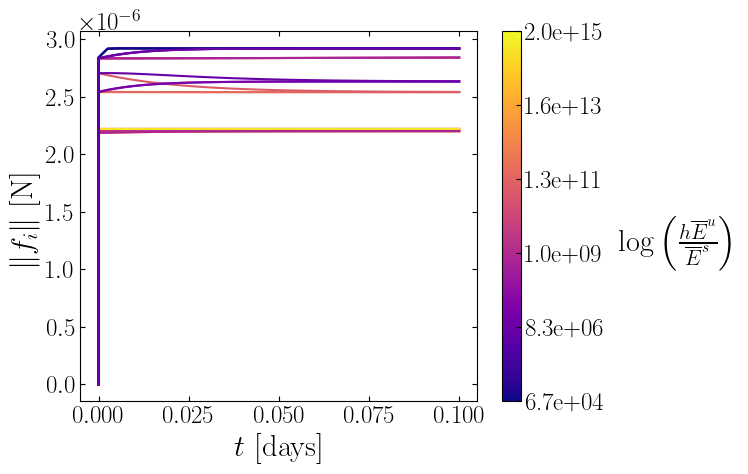

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- extract all a-values as floats
a_vals = [np.abs(float(key[0])) for key in list(parametric_curves_creep.keys()) if key[1]== '1000.00000000']
a_min, a_max = min(a_vals), max(a_vals)
parametric_curves_creep_keys =list( parametric_curves_creep.keys())

select_parametric_curves_creep_dict = {k: parametric_curves_creep[k] for k in parametric_curves_creep_keys[:] if k[1]== '1000.00000000'}
# --- continuous colormap
cmap = plt.colormaps["plasma"]
#norm = plt.Normalize(vmin=a_min, vmax=a_max)
norm = LogNorm(vmin=a_min, vmax=a_max)

fig, ax = plt.subplots()

# --- loop and plot each curve with its own color
for (a, b), data_entry in select_parametric_curves_creep_dict.items():
    a_float = np.abs(float(a))  # force numeric
    color = cmap(norm(a_float))
    time, displacement, force, stress = data_entry
    ax.plot(time, force, color=color, label=f"a={a_float:.9g}")

ax.set_xlabel("$t$ [days]")
ax.set_ylabel("$ \\|f_i\\|$ [N]", color='k')  

# --- scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{h\\overline{E}^u}{\\overline{E}^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

tick_vals = np.logspace(np.log10(a_min), np.log10(a_max), 6)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{val:.1e}" for val in tick_vals])  # scientific notation

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_E0_e-4_force_a.pdf", bbox_inches="tight")
plt.show()

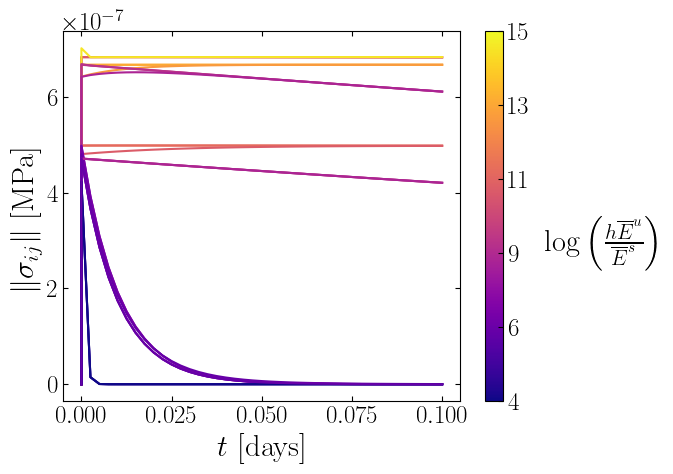

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- extract all a-values as floats
a_string = [key[0] for key in list(parametric_curves_creep.keys())]
a_vals = [np.abs(float(key[0])) for key in list(parametric_curves_creep.keys())]
b_string = [key[1] for key in list(parametric_curves_creep.keys())]
b_vals = [float(key[1]) for key in list(parametric_curves_creep.keys())]
a_min, a_max = min(a_vals), max(a_vals)
b_min, b_max = min(b_vals), max(b_vals)

parametric_curves_creep_keys =list( parametric_curves_creep.keys())

select_parametric_curves_creep_dict = {k: parametric_curves_creep[k] for k in parametric_curves_creep_keys[:] if k[1]== b_string[2]}
# --- continuous colormap
cmap = plt.colormaps["plasma"]
#norm = plt.Normalize(vmin=a_min, vmax=a_max)
norm = LogNorm(vmin=a_min, vmax=a_max)

fig, ax = plt.subplots()

# --- loop and plot each curve with its own color
for (a, b), data_entry in select_parametric_curves_creep_dict.items():
    a_float = np.abs(float(a))  # force numeric
    color = cmap(norm(a_float))
    time, displacement, force, stress = data_entry
    ax.plot(time, stress, color=color, label=f"a={a_float:.9g}")

ax.set_xlabel("$t$ [days]")


ax.set_ylabel("$\\|\\sigma_{ij}\\|$  [MPa]", color='k')  

# --- scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{h\\overline{E}^u}{\\overline{E}^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')

tick_vals = np.logspace(np.log10(a_min), np.log10(a_max), 6)
cbar.set_ticks(tick_vals)

cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_E0_e-4_surface_stress_a.pdf", bbox_inches="tight")
plt.show()

### Plots for the nondimesional number $\frac{\tau^u}{\tau^s}$

In [8]:
from collections import defaultdict

# Suppose parametric_curves_creep is your original dict
grouped_by_a = defaultdict(dict)

for (a, b), val in parametric_curves_creep.items():
    grouped_by_a[a][b] = val

# Convert back to a normal dict (optional)
grouped_by_a = dict(grouped_by_a)

# --- Inspect ---
#for a, subdict in grouped_by_a.items():
#    print(f"a = {a}")
#    for b, v in subdict.items():
#        print(f"   b = {b} → value shape/type: {type(v)}")


In [9]:
grouped_by_a_clean = {
    a: {
        b: data_entry
        for b, data_entry in subdict.items()
        if not any(np.isnan(np.asarray(arr)).any() for arr in data_entry)   # no NaNs
        and all(len(np.atleast_1d(arr)) > 1 for arr in data_entry)          # each array > 1 entry
    }
    for a, subdict in grouped_by_a.items()
}

filtered_grouped_by_a = {
    a: subdict
    for a, subdict in grouped_by_a_clean.items()
    if len(subdict) >= 4   # keep groups with enough entries
}

In [10]:
#n_nan = 0
#
#for a, subdict in filtered_grouped_by_a.items():
#    for b, data_entry in subdict.items():
        # convert each entry to np.array to handle lists or tuples
#        arrays = list(map(np.asarray, data_entry))
#        if any(np.isnan(arr).any() for arr in arrays):
#            print(f"⚠️ NaN detected in a={a}, b={b}")
#            n_nan += 1

#if n_nan == 0:
#    print("✅ No NaN values found in filtered_grouped_by_a.")
#else:
#    print(f"⚠️ Found {n_nan} entries containing NaNs.")

In [11]:
# --- Step 1: list available 'a' keys ---
a_keys_filtered = list(filtered_grouped_by_a.keys())
print("Available a keys:")
for i, a in enumerate(a_keys_filtered):
    print(f"[{i}] a = {a}")

# --- Step 2: choose which 'a' values you want ---
selected_indices = [0, 2, 4, 10, 16, 19]  # change to whichever 3 you want
selected_a_values = [a_keys_filtered[i] for i in selected_indices if i < len(a_keys_filtered)]
# print("Selected a values:", selected_a_values)
common_b_keys = list(filtered_grouped_by_a[selected_a_values[0]].keys())
# Convert b keys to floats for log-scaling
b_values = np.array([float(b) for b in common_b_keys])

Available a keys:
[0] a = -1.9994001e+11
[1] a = -1.9994002e+13
[2] a = -1.960592e+11
[3] a = -1.9605921e+13
[4] a = -6.6664443e+10
[5] a = -6.6664444e+12
[6] a = -6.6664444e+14
[7] a = -1.9994001e+09
[8] a = -1.9994002e+11
[9] a = -1.960592e+09
[10] a = -1.9605921e+11
[11] a = -6.6664443e+08
[12] a = -6.6664444e+10
[13] a = -19994001
[14] a = -1.9994002e+09
[15] a = -19605920
[16] a = -1.9605921e+09
[17] a = -6666444.3
[18] a = -6.6664444e+08
[19] a = -199940.01
[20] a = -19994002
[21] a = -196059.2
[22] a = -19605921
[23] a = -66664.443
[24] a = -6666444.4


In [12]:
## Pick one key pair manually (for example, the first one)
#a_keys_filtered = next(iter(filtered_grouped_by_a))                   # first 'a'
#b_key = next(iter(filtered_grouped_by_a[a_keys_filtered]))            # first 'b'

# Access the data tuple
#time, displacement, force, stress = filtered_grouped_by_a[a_keys_filtered][b_key]

# Choose one array to inspect, e.g. 'stress'
#array_to_check = np.asarray(stress)

#print(f"a = {a_keys_filtered}, b = {b_key}")
#print(f"Array shape: {array_to_check.shape}")
#print(f"Array size: {array_to_check.size}")

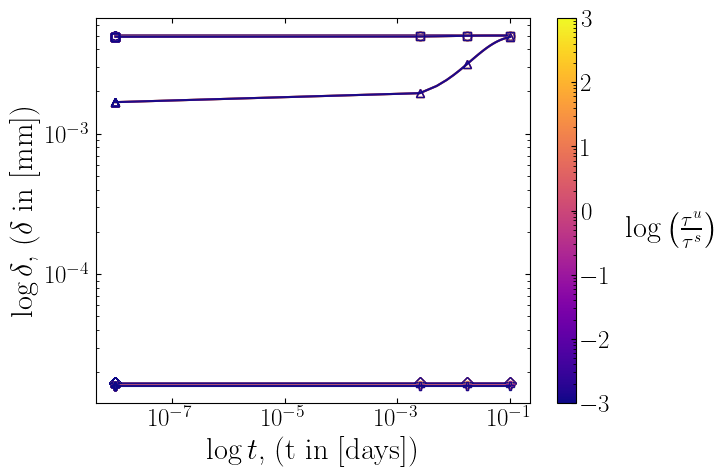

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- Define linestyles for different 'a's ---
# --- Define markers for each 'a' ---
markers = ['o', 's', '^', 'D', 'v', 'P']  # add more if needed

# --- Set up colormap (logarithmic) ---
cmap = plt.colormaps["plasma"]
norm = LogNorm(vmin=b_values.min(), vmax=b_values.max())

# --- Define distinct linestyles for different a's ---
# --- Create figure and axes explicitly ---
fig, ax = plt.subplots(figsize=(7, 5))

# --- Plot all curves ---
for i, a in enumerate(selected_a_values):
    subdict = filtered_grouped_by_a[a]
    #ls = linestyles[i % len(linestyles)]
    marker = markers[i % len(markers)]
    for b_str in common_b_keys:
        b = float(b_str)
        time, displacement, force, stress = subdict[b_str]
        # print(time)
        color = cmap(norm(b))
        # remove zeros or negatives (log scale can’t handle them)
        valid = (time > 0) & (displacement > 0)
        time = time[valid]
        displacement = displacement[valid]
        
        # compute log–spaced marker positions
        n_markers = 10
        log_times = np.logspace(np.log10(time.min()), np.log10(time.max()), n_markers)
        #print(log_times)
        markevery = [np.argmin(np.abs(time - t)) for t in log_times]

        
        ax.plot(
            time, displacement,
            marker=marker,
            markevery= markevery,#max(len(time)//15, 1),
            markersize=6,             # smaller marker
            markerfacecolor='none',   # hollow marker
            markeredgecolor=color,    # edge same as line color
            markeredgewidth=1,
            linestyle='-',
            color=color,
            alpha=0.9,
            label=f"a={a}, b={b:g}"
        )

ax.set_xscale("log")
ax.set_xlabel("$\\log t$, (t in [days])")

ax.set_yscale("log")      # ← make y-axis logarithmic
ax.set_ylabel("$\\log\\delta$, ($\\delta$ in  [mm])", color='k')  

# --- Add colorbar explicitly tied to 'ax' ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=ax)
#cbar.set_label("b value (log scale)")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{\\tau^u}{\\tau^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_E0_e-4_displacement_b.pdf", bbox_inches="tight")
plt.show()
plt.tight_layout()
plt.show()

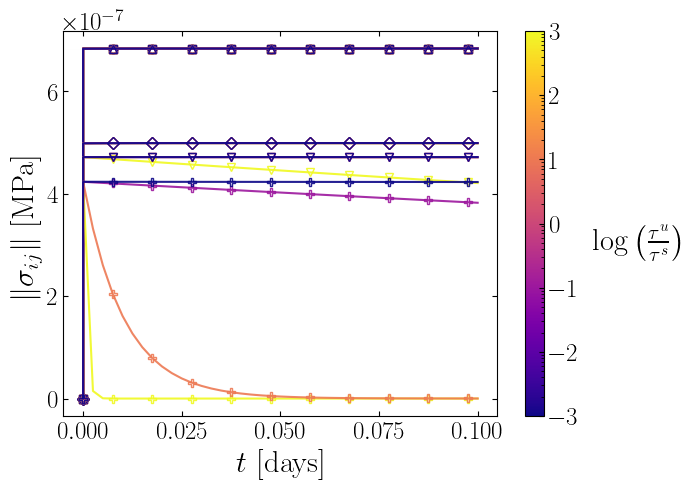

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- Define linestyles for different 'a's ---
# --- Define markers for each 'a' ---
markers = ['o', 's', '^', 'D', 'v', 'P']  # add more if needed

# --- Set up colormap (logarithmic) ---
cmap = plt.colormaps["plasma"]
norm = LogNorm(vmin=b_values.min(), vmax=b_values.max())

# --- Define distinct linestyles for different a's ---
# --- Create figure and axes explicitly ---
fig, ax = plt.subplots(figsize=(7, 5))

# --- Plot all curves ---
for i, a in enumerate(selected_a_values):
    subdict = filtered_grouped_by_a[a]
    #ls = linestyles[i % len(linestyles)]
    marker = markers[i % len(markers)]
    for b_str in common_b_keys:
        b = float(b_str)
        time, displacement, force, stress = subdict[b_str]
        color = cmap(norm(b))
        ax.plot(
            time, stress,
            marker=marker,
            markevery=max(len(time)//10, 1),
            markersize=6,             # smaller marker
            markerfacecolor='none',   # hollow marker
            markeredgecolor=color,    # edge same as line color
            markeredgewidth=1,
            linestyle='-',
            color=color,
            alpha=0.9,
            label=f"a={a}, b={b:g}"
        )

ax.set_xlabel("$t$ [days]")
ax.set_ylabel("$\\|\\sigma_{ij}\\|$  [MPa]", color='k')  

# --- Add colorbar explicitly tied to 'ax' ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=ax)
#cbar.set_label("b value (log scale)")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{\\tau^u}{\\tau^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_E0_e-4_surface_stress_b.pdf", bbox_inches="tight")
plt.show()
plt.tight_layout()
plt.show()

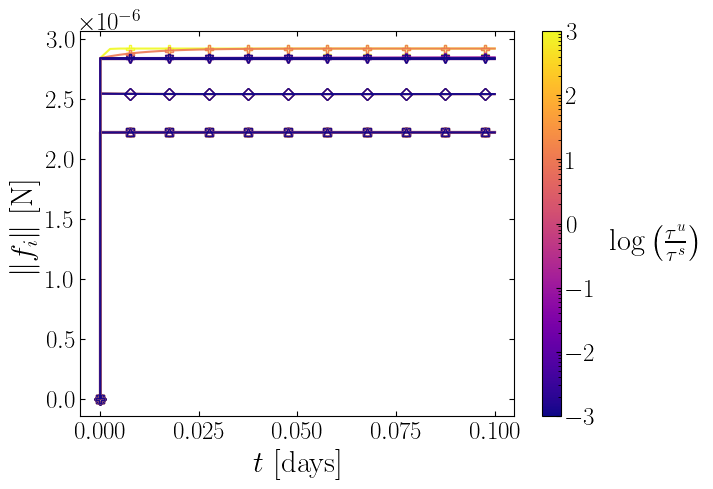

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- Define linestyles for different 'a's ---
# --- Define markers for each 'a' ---
markers = ['o', 's', '^', 'D', 'v', 'P']  # add more if needed

# --- Set up colormap (logarithmic) ---
cmap = plt.colormaps["plasma"]
norm = LogNorm(vmin=b_values.min(), vmax=b_values.max())

# --- Define distinct linestyles for different a's ---
# --- Create figure and axes explicitly ---
fig, ax = plt.subplots(figsize=(7, 5))

# --- Plot all curves ---
for i, a in enumerate(selected_a_values):
    subdict = filtered_grouped_by_a[a]
    #ls = linestyles[i % len(linestyles)]
    marker = markers[i % len(markers)]
    for b_str in common_b_keys:
        b = float(b_str)
        time, displacement, force, stress = subdict[b_str]
        color = cmap(norm(b))
        ax.plot(
            time, force,
            marker=marker,
            markevery=max(len(time)//10, 1),
            markersize=6,             # smaller marker
            markerfacecolor='none',   # hollow marker
            markeredgecolor=color,    # edge same as line color
            markeredgewidth=1,
            linestyle='-',
            color=color,
            alpha=0.9,
            label=f"a={a}, b={b:g}"
        )

ax.set_xlabel("$t$ [days]")
ax.set_ylabel("$\\|f_{i}\\|$  [N]", color='k')  

# --- Add colorbar explicitly tied to 'ax' ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=ax)
#cbar.set_label("b value (log scale)")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{\\tau^u}{\\tau^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_E0_e-4_force_b.pdf", bbox_inches="tight")
plt.show()
plt.tight_layout()
plt.show()

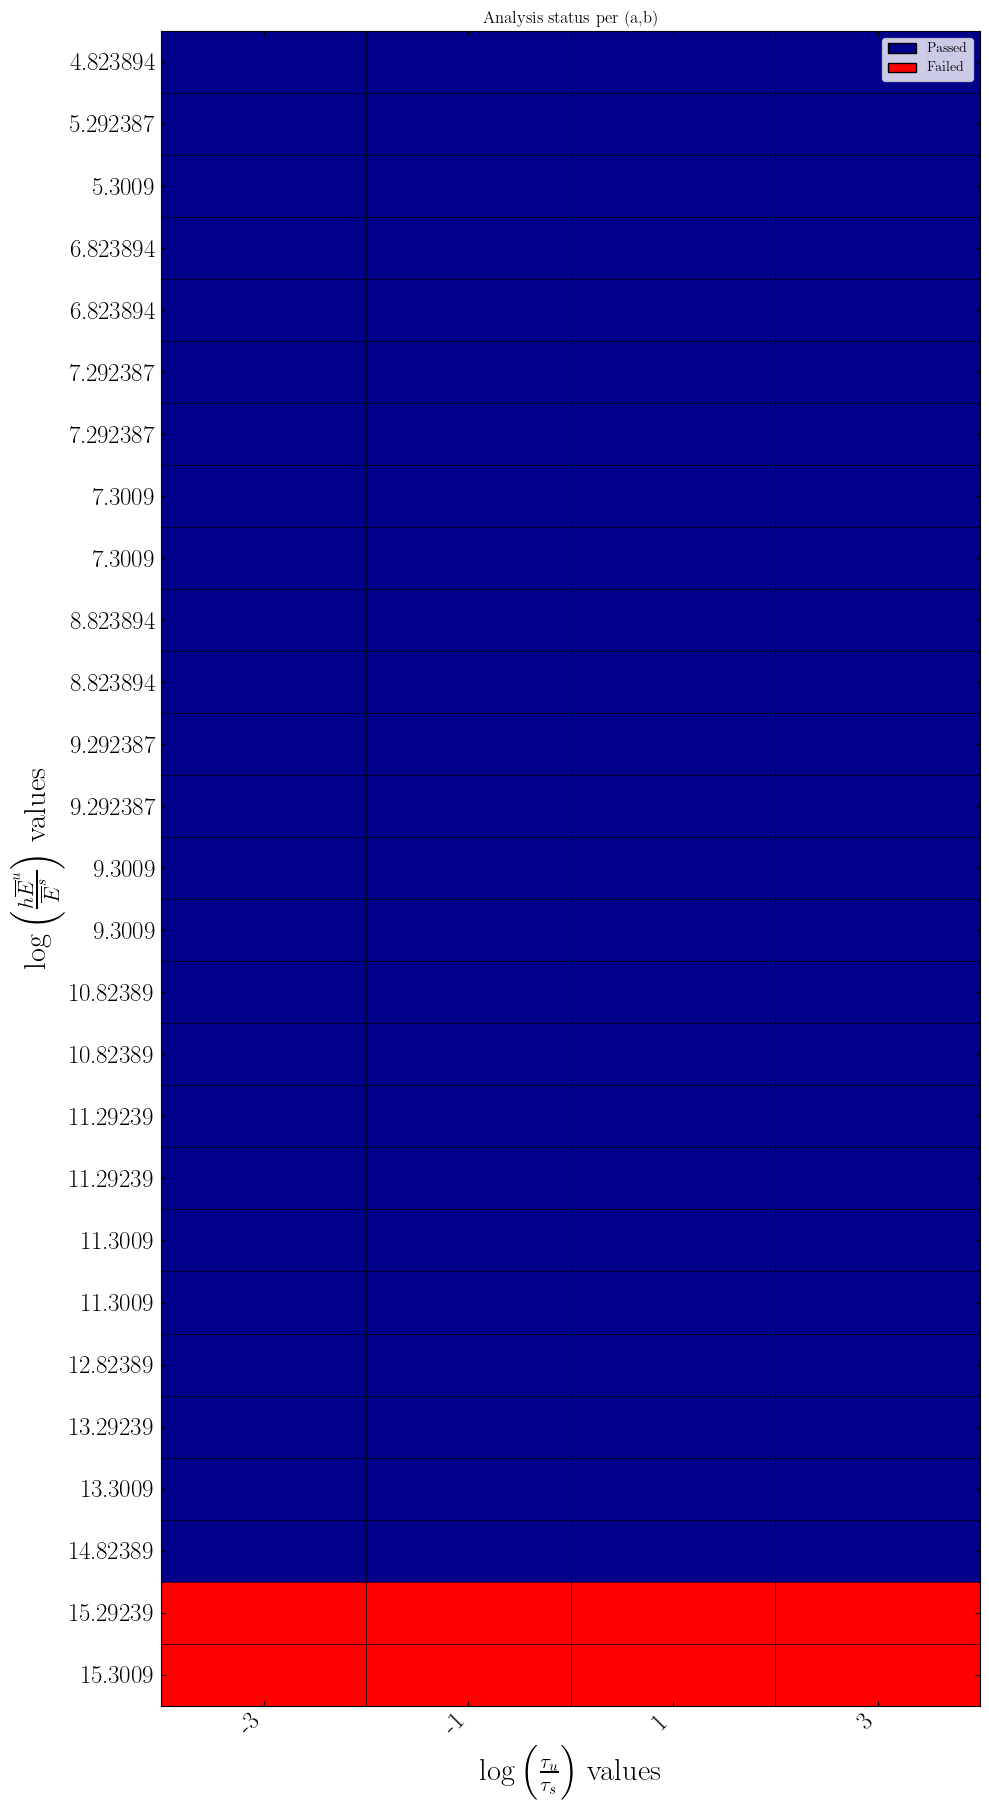

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# --- Normalize keys of both dictionaries to float ---
def normalize_dict(d):
    return {
        float(a): {float(b): v for b, v in sub.items()}
        for a, sub in d.items()
    }

grouped_by_a = normalize_dict(grouped_by_a)
filtered_grouped_by_a = normalize_dict(filtered_grouped_by_a)

# --- Collect all a and b values ---
all_a = sorted(grouped_by_a.keys())
all_b = sorted(set(b for sub in grouped_by_a.values() for b in sub.keys()))
# --- Use logarithm for a-axis ---
log_all_a = [np.log10(np.abs(a)) for a in all_a]
log_all_b = [np.log10(np.abs(b)) for b in all_b]

n_a = len(all_a)
n_b = len(all_b)

# --- Build grid: 1 = passed, -1 = failed ---
grid = np.zeros((n_a, n_b), dtype=int)
for i, a in enumerate(all_a):
    for j, b in enumerate(all_b):
        if a in filtered_grouped_by_a and b in filtered_grouped_by_a[a]:
            grid[i, j] = 1   # passed
        else:
            grid[i, j] = -1  # failed

# --- Colormap: red for fail, darkblue for pass ---
cmap = ListedColormap(["red", "darkblue"])

# --- Figure dimensions ---
cell_w = 1.2   # width per column
cell_h = 0.6   # height per row
fig_w = max(10, cell_w * n_b + 2)
fig_h = max(5,  cell_h * n_a + 2)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
im = ax.imshow(grid, cmap=cmap, origin="lower", aspect="auto")

# --- Ticks and labels ---
ax.set_xticks(range(n_b))
ax.set_xticklabels([f"{b:.3g}" for b in log_all_b], rotation=45, ha="right")
ax.set_yticks(range(n_a))
#ax.set_yticklabels([f"{a:.3g}" for a in all_a])
#ax.set_yticklabels([f"1e{int(val)}" for val in log_all_a])  # log10 labels like 1e12, 1e14, ...
ax.set_yticklabels([f"{a:.7g}" for a in log_all_a])  # 6 significant digits, scientific notation

ax.set_xlabel("$\\log\\left(\\frac{\\tau_u}{\\tau_s}\\right)$ values")
ax.set_ylabel("$\\log\\left(\\frac{h \\overline{E}^u}{\\overline{E}^s}\\right)$ values")
ax.set_title("Analysis status per (a,b)")

# --- Grid lines to separate rectangles ---
ax.set_xticks(np.arange(-.5, n_b, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_a, 1), minor=True)
ax.grid(which="minor", color="k", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# --- Legend ---
legend_elements = [
    Patch(facecolor="darkblue", edgecolor="k", label="Passed"),
    Patch(facecolor="red", edgecolor="k", label="Failed"),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()